In [1]:
# 温度、湿度、温湿度都绘制
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Times New Roman']  # 指定默认
plt.rcParams['axes.unicode_minus'] = False
# ===== 配置 =====

In [2]:
stl = pd.read_excel("D:/Permafrost/EN_MASK/stmi/stl/stl.xlsx", index_col=0) - 273.15 # 读取Excel文件，假设第一列是时间索引
swvl = pd.read_excel('D:/Permafrost/EN_MASK/stmi/swvl/swvl.xlsx', index_col=0)  # 读取Excel文件，假设第一列是时间索引

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
# 示例数据（假设 stl['stl1'] 和 swvl['swvl1'] 是你自己的数据）
stl_ = ['stl1', 'stl2', 'stl3', 'stl4']
swvl_ = ['swvl1', 'swvl2', 'swvl3', 'swvl4']
colors = ["#89B3D2", "#6482D4", "#3E82BE", "#226297"]
i = 0
y_ = [0.88,0.83,0.78,0.73]
y_1 = [0.23,0.18,0.13,0.08]
plt.figure(figsize=(6, 6))
for stl1, swvl1 in zip(stl_, swvl_):
    x = stl[stl1]  # 温度变量
    y = swvl[swvl1]  # 湿度变量
    # 0度之前的数据
    mask_below_0 = x < 0
    x_below_0 = x[mask_below_0]
    y_below_0 = y[mask_below_0]
    # 0度之后的数据
    mask_above_0 = x >= 0
    x_above_0 = x[mask_above_0]
    y_above_0 = y[mask_above_0]
    # 对0度之前的数据进行线性回归
    slope_below_0, intercept_below_0, r_value_below_0, p_value_below_0, std_err_below_0 = linregress(x_below_0, y_below_0)
    r_squared_below_0 = r_value_below_0 ** 2
    # 对0度之后的数据进行线性回归
    slope_above_0, intercept_above_0, r_value_above_0, p_value_above_0, std_err_above_0 = linregress(x_above_0, y_above_0)
    r_squared_above_0 = r_value_above_0 ** 2
    # 绘制散点图
    sns.scatterplot(x=x, y=y, color=colors[i])
    # 绘制0度之前的数据拟合直线
    sns.regplot(x=x_below_0, y=y_below_0, scatter=False, color=colors[i], line_kws={"color": colors[i], "linewidth": 2})
    # 绘制0度之后的数据拟合直线
    sns.regplot(x=x_above_0, y=y_above_0, scatter=False, color=colors[i], line_kws={"color": colors[i], "linewidth": 2})
    # 显示拟合的方程、R²和P值  y = {slope_below_0:.3f}x + {intercept_below_0:.2f}\n y = {slope_above_0:.3f}x + {intercept_above_0:.2f}\n
    if p_value_below_0 < 0.05 and p_value_above_0 < 0.05:
        equation_text_below_0 = f'R² = {r_squared_below_0:.2f} p < 0.05'
        equation_text_above_0 = f'R² = {r_squared_above_0:.2f} p < 0.05'
    else:
        equation_text_below_0 = f'R² = {r_squared_below_0:.2f} p = {p_value_below_0:.2f}'
        equation_text_above_0 = f'R² = {r_squared_above_0:.2f} p = {p_value_above_0:.2f}'
    plt.text(0.7, y_[i], equation_text_below_0, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color=colors[i])
    plt.text(0.37, y_1[i], equation_text_above_0, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color=colors[i])
    i += 1
# 添加标题和标签
plt.text(0.7, 0.93, 'After 0°C:', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color="#0A3384")
plt.text(0.37, 0.28, 'Before 0°C:', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color="#0A3384")
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('ST (°C)', fontsize=15)
plt.ylabel('SW (m³/m³)', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
# 显示图形
plt.show()

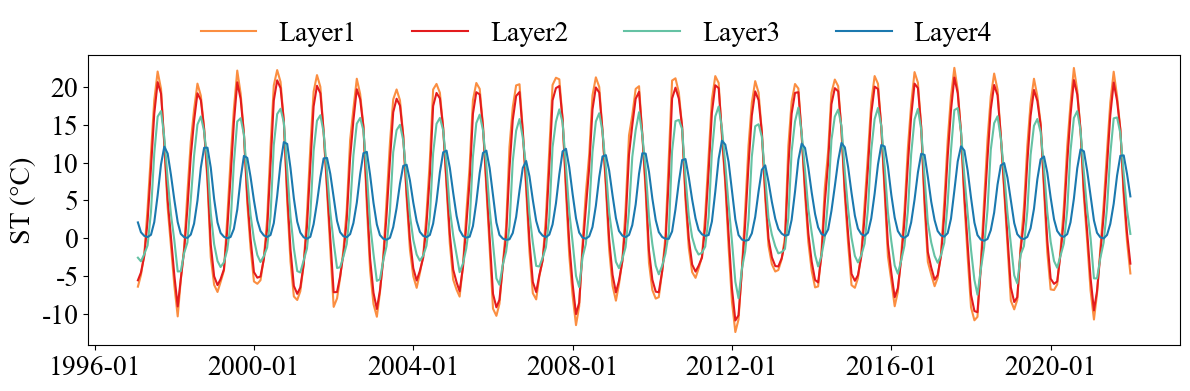

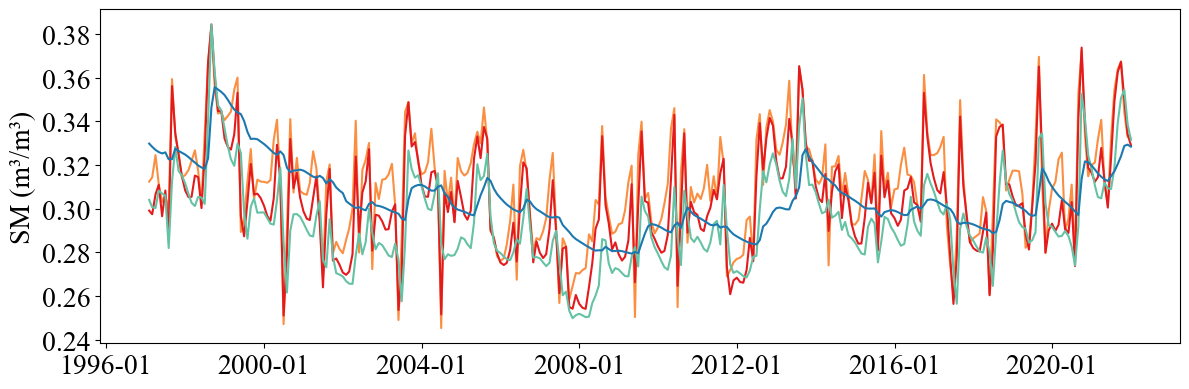

In [95]:
# stl swvl的月尺度趋势
colors1 = ['#fb8e41', '#e31b1e', '#65c2a4', '#1b79af']
def plt_stl(stl1, stl2, stl3, stl4, lable):
    plt.figure(figsize=(12, 4))
    dates = pd.date_range(start='1997-01', end='2022-01', freq='M')
    # 绘制每一层土壤温度
    plt.plot(dates, stl1, label='Layer1', color=colors1[0])  
    plt.plot(dates, stl2, label='Layer2', color=colors1[1])
    plt.plot(dates, stl3, label='Layer3', color=colors1[2])
    plt.plot(dates, stl4, label='Layer4', color=colors1[3])
    # 添加标签和标题
    plt.xlabel('', fontsize=20)
    plt.ylabel(lable, fontsize=20)
    # plt.title('Monthly Soil Temperature from 1997 to 2021')
    # 显示图例
    if lable=='ST (°C)':plt.legend(fontsize=20, ncol=4, bbox_to_anchor=(0.08, 0.94), frameon=False, edgecolor='none')
    # 格式化日期显示
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # 显示网格
    # plt.grid(True)
    # 调整布局
    plt.tight_layout()
    # 展示图形
    plt.show()
plt_stl(stl['stl1'], stl['stl2'], stl['stl3'], stl['stl4'], 'ST (°C)')
plt_stl(swvl['swvl1'], swvl['swvl2'], swvl['swvl3'], swvl['swvl4'], 'SM (m³/m³)')

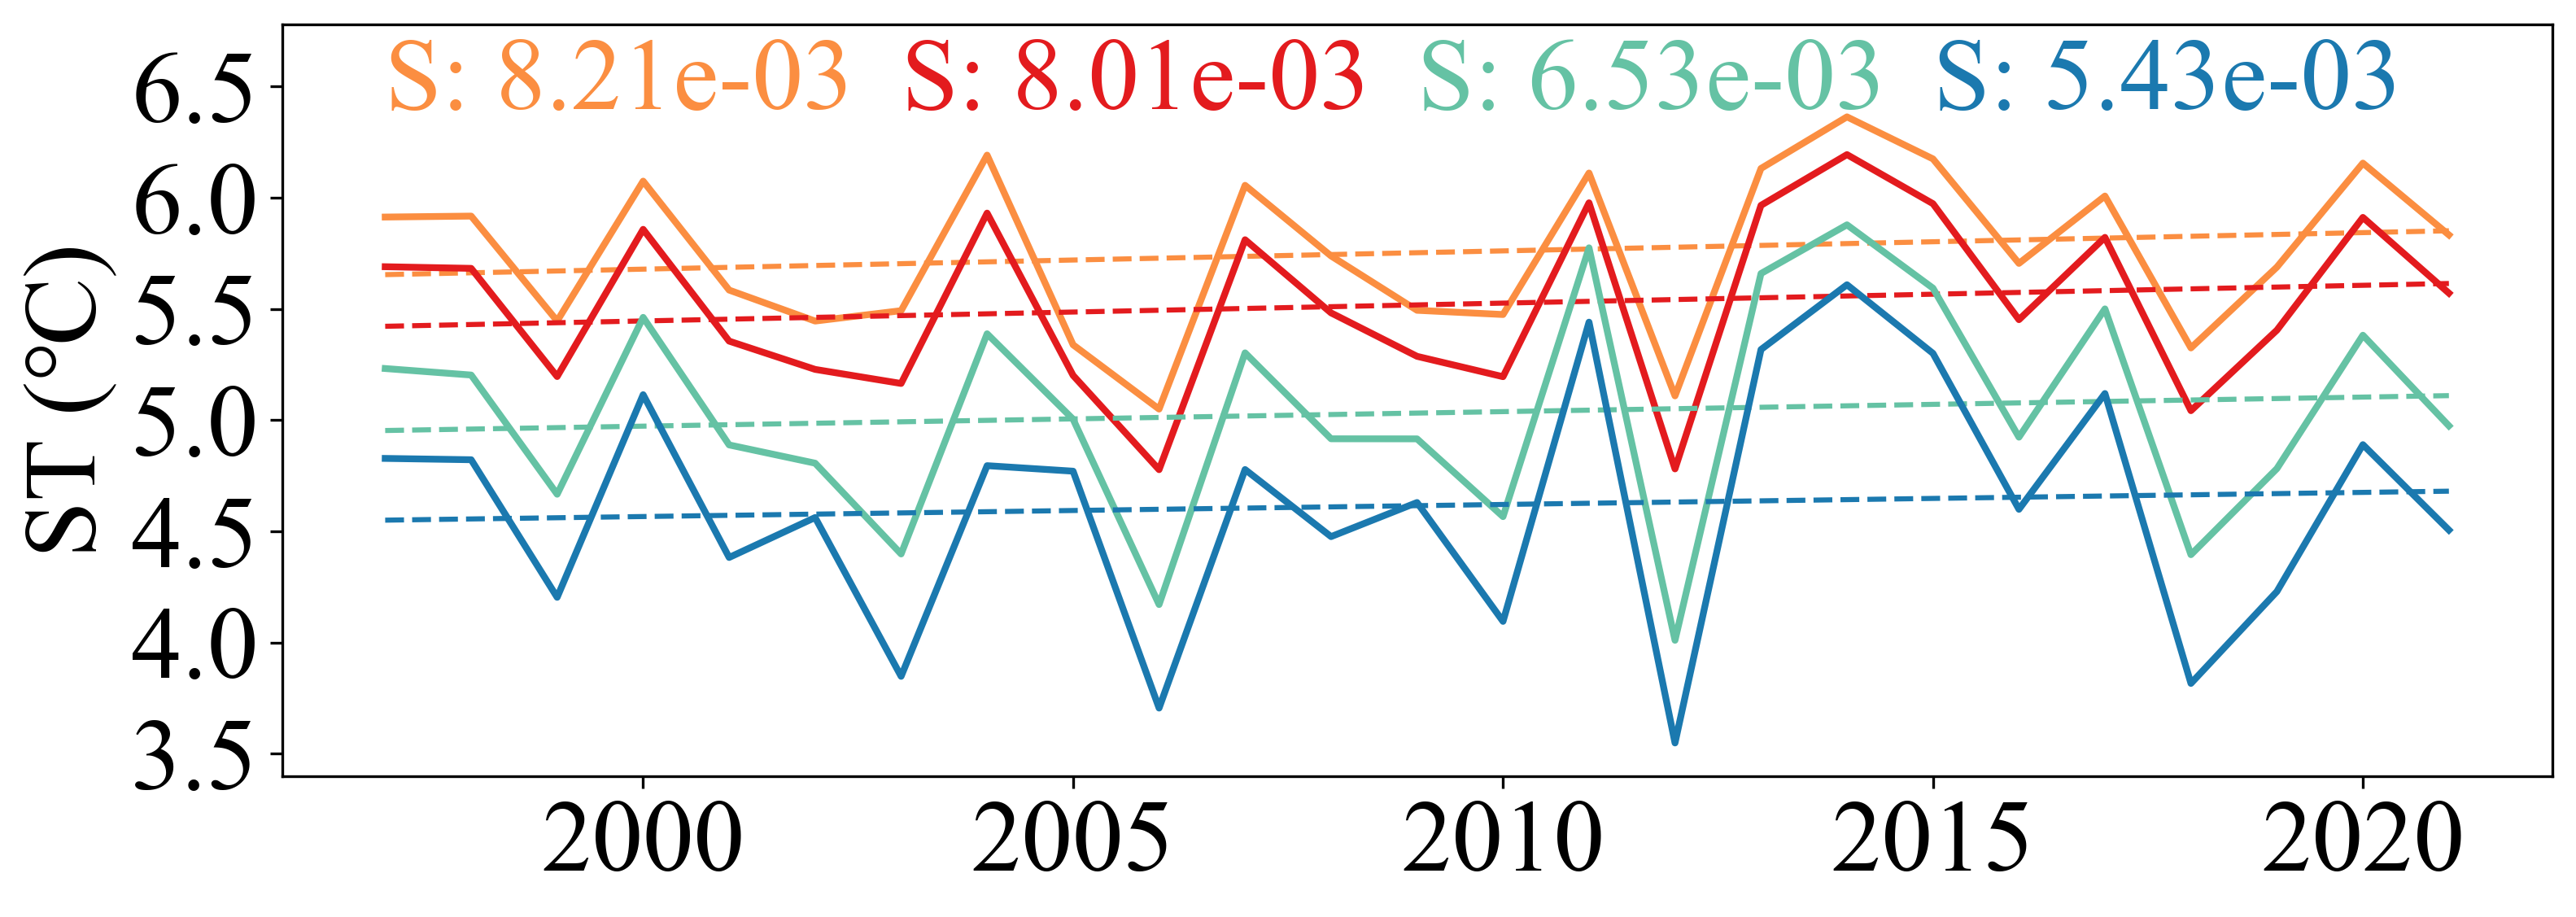

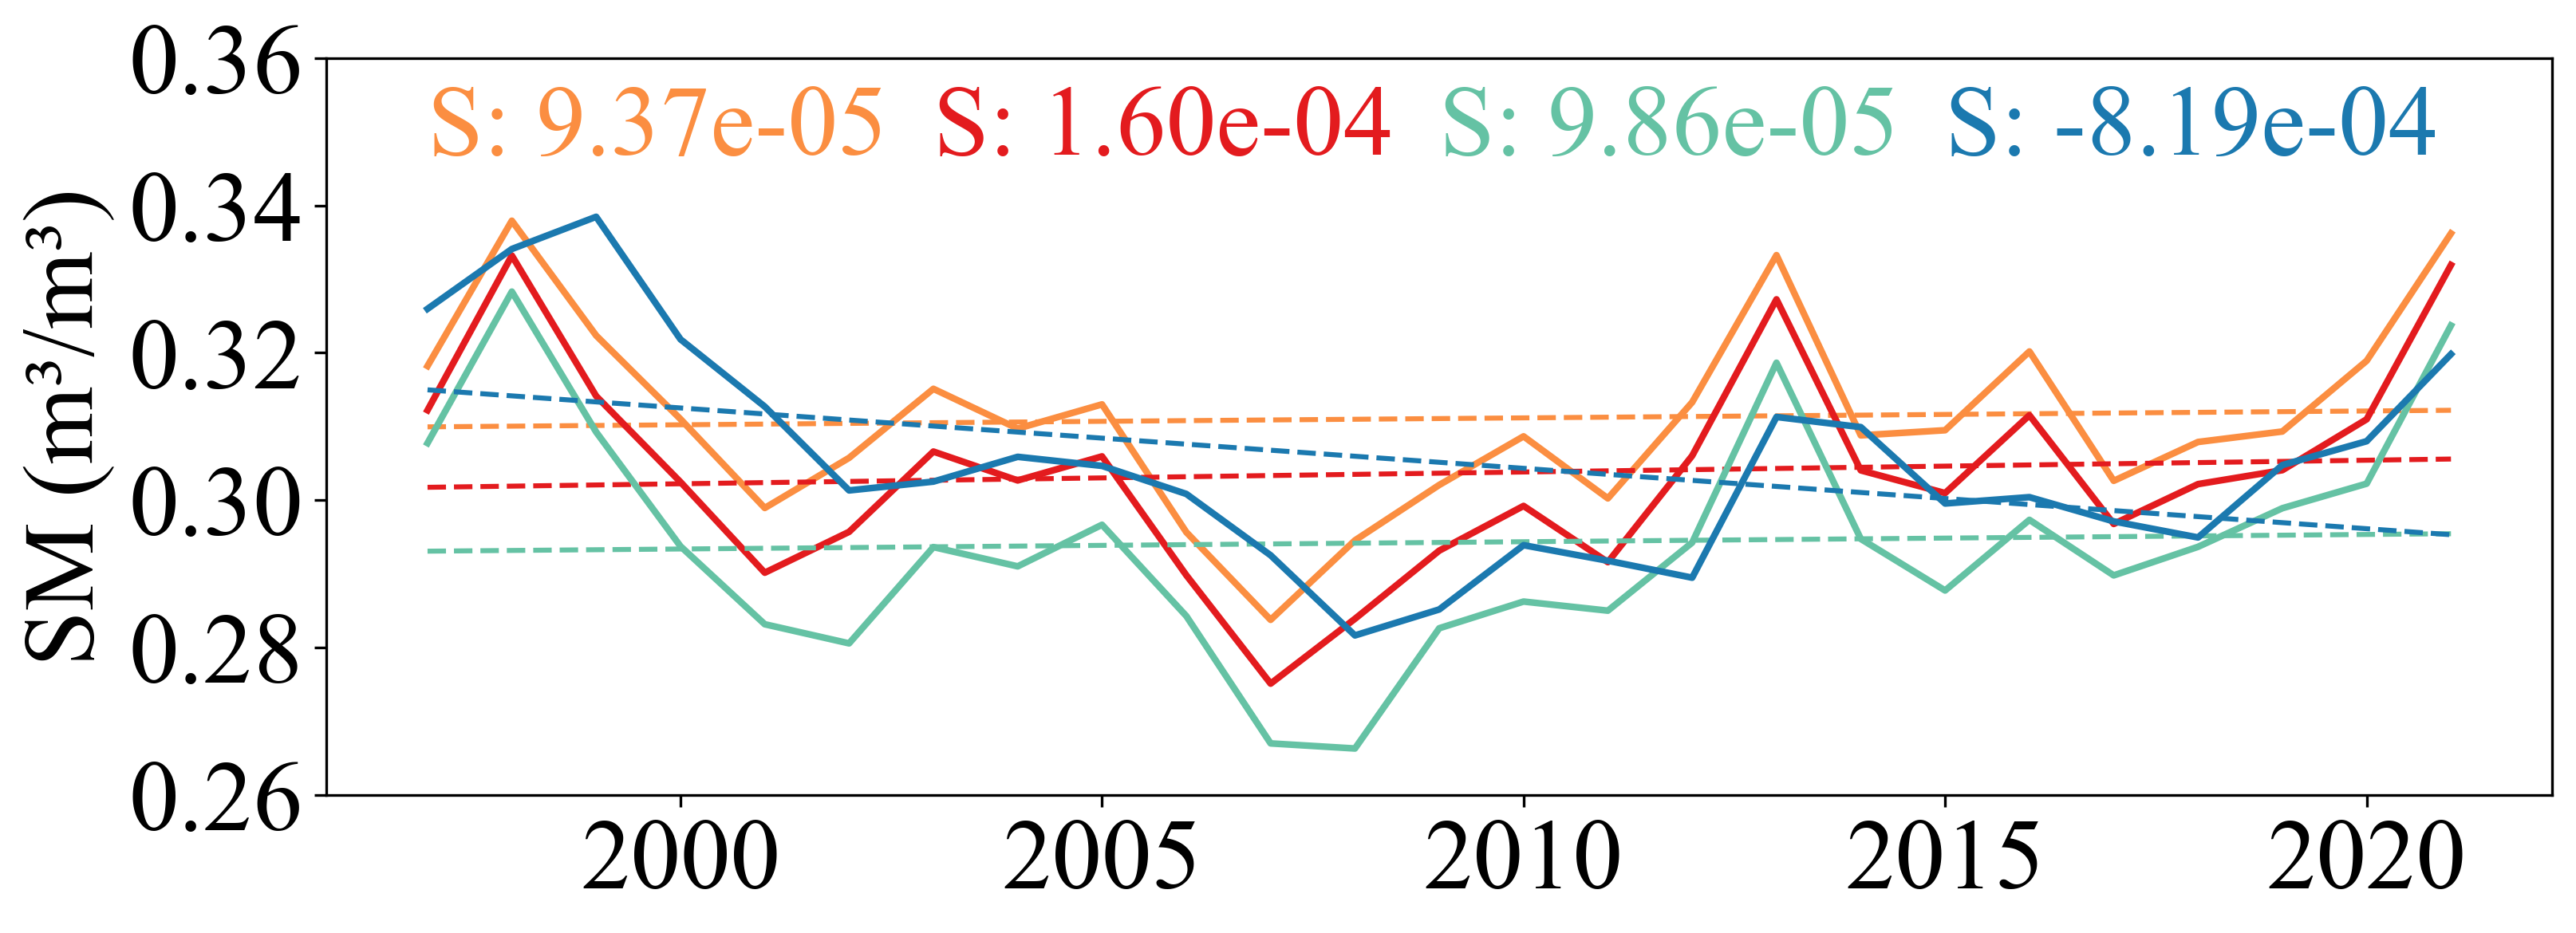

In [71]:
# 温湿度，指数年均趋势 带slpoe
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
def plot_with_regression_line(data, ylabel, ps, colors, x_year):
    data.index = pd.to_datetime(data.index)
    data["Year"] = data.index.year
    # 2. 按年分组，准备每年的 12 个“整体均值” → 箱型图数据
    years = sorted(data["Year"].unique())
    # 3. 年均值（四层分别）已经在 data_y 里
    # 如果还没有，可以这样算：
    data_y = data.groupby("Year").mean().iloc[:, :]  # 去掉 Year 列
    # data_m = data['mean'].resample('A').mean()
    # 4. 绘图
    plt.figure(figsize=(12, 4), dpi=300)
    # 箱型图：每年一个
    positions = range(1997, 2022)
    layers = ['Layer1', 'Layer2', 'Layer3', 'Layer4']
    # 5. 绘制原始年均值直线和拟合直线（虚线）
    slpoe_l = []
    for a,col in enumerate(data_y.columns):
        # 绘制原始年均值折线
        plt.plot(positions, data_y[col], label=layers[a], color=colors[a], linewidth=2)
        # 线性回归拟合
        slope, intercept, r_value, p_value, std_err = linregress(years, data_y[col])
        # 计算拟合直线的值
        fit_line = [slope * year + intercept for year in years]
        # 绘制拟合直线为虚线
        plt.plot(positions, fit_line, linestyle="--", color=colors[a])
        # trend
        slpoe_l.append(slope)
    plt.text(x_year, ps[0], f"S: {slpoe_l[0]:.2e}", fontsize=30, color=colors[0])
    plt.text(x_year+6, ps[1], f"S: {slpoe_l[1]:.2e}", fontsize=30, color=colors[1])
    plt.text(x_year+12, ps[2], f"S: {slpoe_l[2]:.2e}", fontsize=30, color=colors[2])
    plt.text(x_year+18, ps[3], f"S: {slpoe_l[3]:.2e}", fontsize=30, color=colors[3])
    # if ylabel == "STMI" or ylabel == "Soil temperature (℃)":
    #     plt.axhline(y=0, color='gray', linestyle='--', linewidth=2)
    # plt.xlabel("Year", fontsize=30)
    plt.ylabel(ylabel, fontsize=30)
    plt.yticks(fontsize=30)
    plt.xticks(fontsize=30)
    if ylabel=='ST (℃)':plt.ylim(3.4, 6.78)
    else: plt.ylim(0.26, 0.36)
    # plt.legend(bbox_to_anchor=(0.85, 1.22), fontsize=24, ncol=4, framealpha=0.8, frameon=False)
    # plt.tight_layout()
    plt.show()
colors1 = ['#fb8e41', '#e31b1e', '#65c2a4', '#1b79af']
plot_with_regression_line(stl, "ST (℃)", [6.4, 6.4, 6.4, 6.4], colors1, 1997)
plot_with_regression_line(swvl, "SM (m³/m³)", [0.347, 0.347, 0.347, 0.347], colors1, 1997)

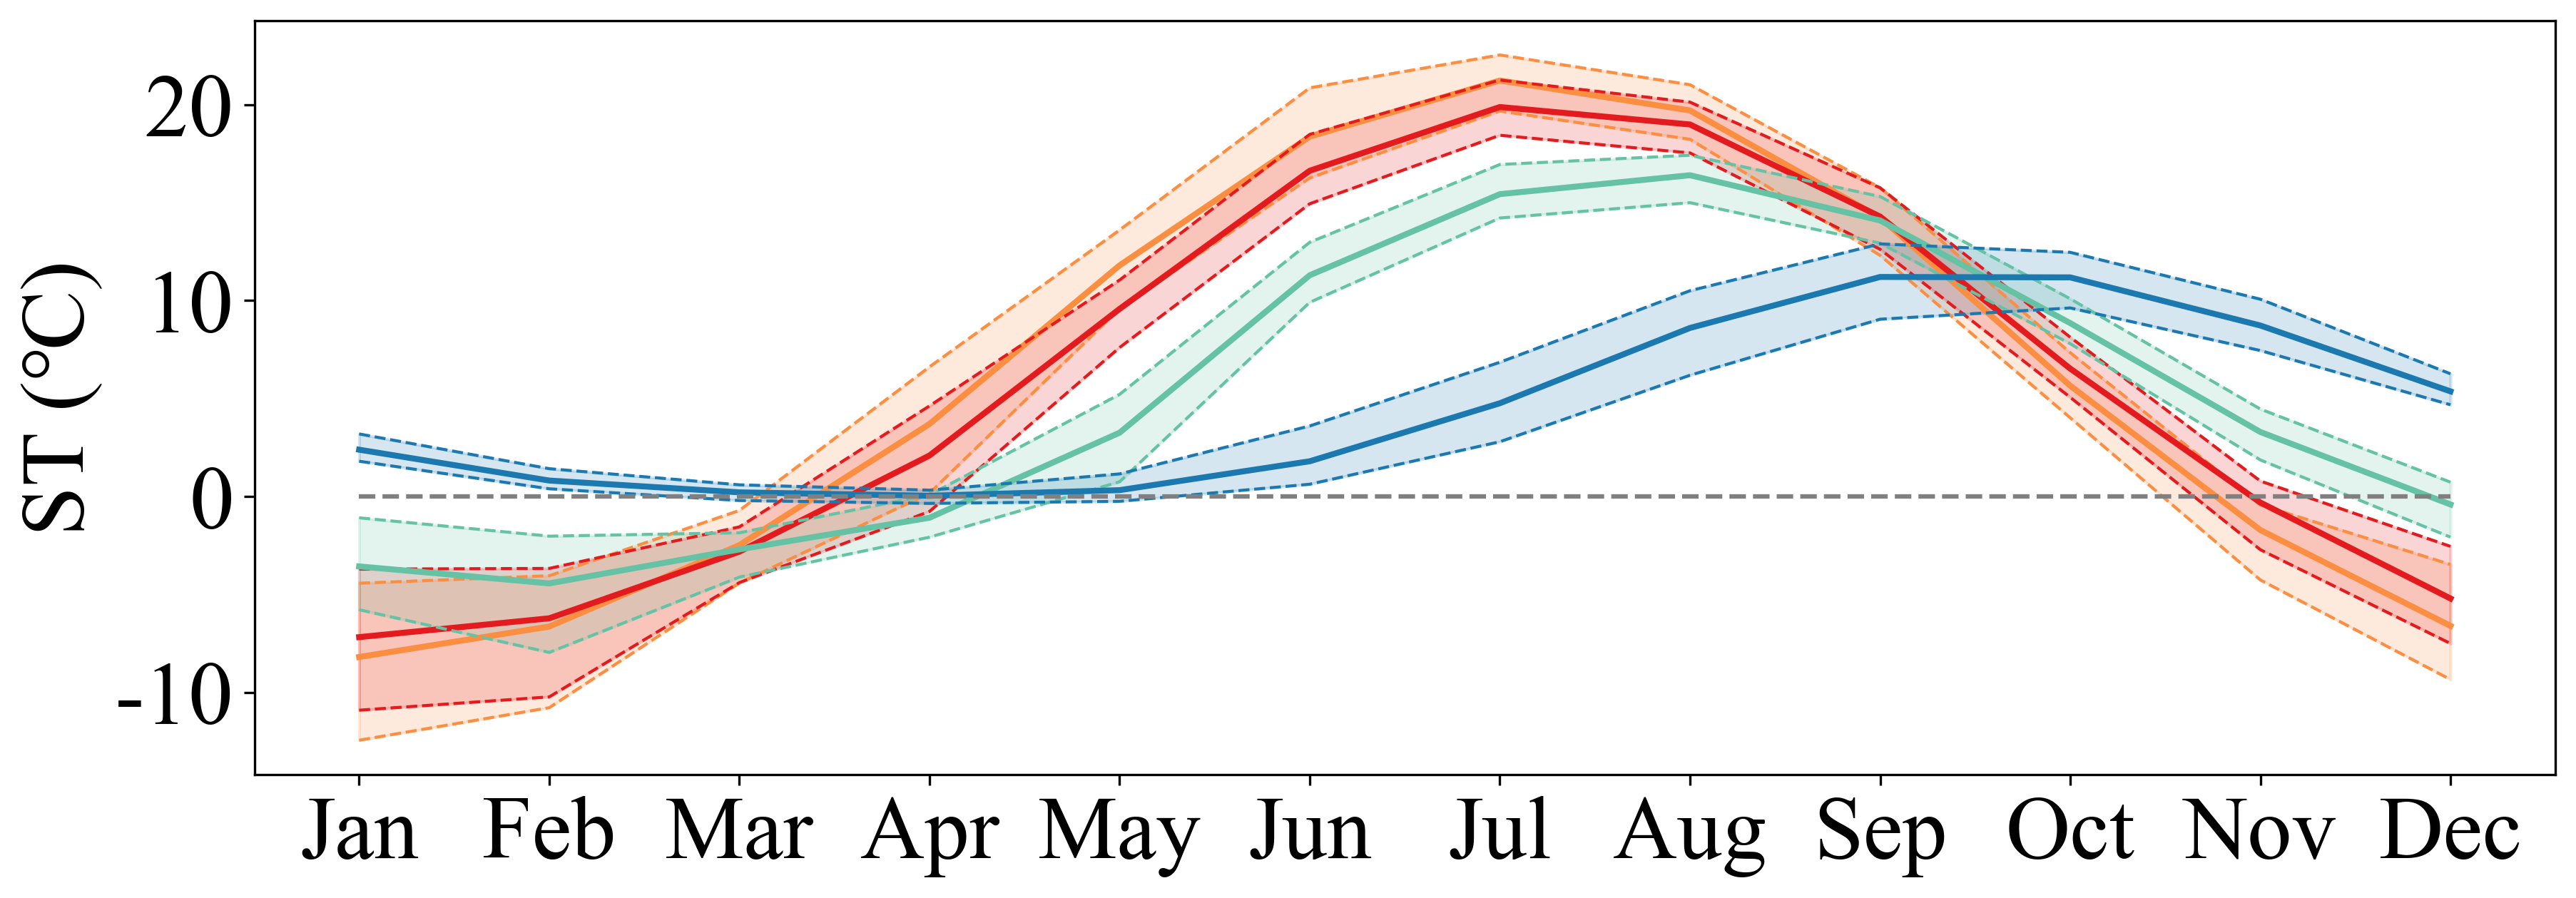

In [92]:
# 温度 25年上平均的12月趋势
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ========= 可修改区域 =========
excel_path = 'D:/Permafrost/EN_MASK/stmi/stl/stl.xlsx'  # << 替换为你的Excel路径
sheet_name = 'Sheet1'                             # 或者填写工作表名
layer_cols = ["stl1", "stl2", "stl3", "stl4"] # 如果列名不同，在这里改

# 如果只想用一个固定的25年窗口，打开下面两行：
# year_start, year_end = 1997, 2021           # << 示例：1997-2021 共25年（含端点）
year_start, year_end = None, None              # << 默认None表示用全时段
alpha_shade = 0.18                             # 阴影透明度
# ============================

# 读取
df = pd.read_excel(excel_path, sheet_name=sheet_name)
df.columns = [str(c).strip() for c in df.columns]

# 忽略 mean 列
df = df.drop(columns=[c for c in df.columns if c.lower() == "mean"], errors="ignore")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["year"]  = df["Date"].dt.year
df["month"] = df["Date"].dt.month

# 按需限制到 25 年窗口
if (year_start is not None) and (year_end is not None):
    df = df[(df["year"] >= year_start) & (df["year"] <= year_end)].copy()

# —— 计算统计量：每月多年均值、以及每月 across years 的最小/最大值 ——
# 多年均值（climatology）
mean_df = (df.groupby("month")[layer_cols].mean(numeric_only=True).reindex(range(1, 12 + 1)))

# 每月最小/最大（跨年份）
min_df = (
    df.groupby("month")[layer_cols]
      .min(numeric_only=True)
      .reindex(range(1, 12 + 1))
)
max_df = (
    df.groupby("month")[layer_cols]
      .max(numeric_only=True)
      .reindex(range(1, 12 + 1))
)

# —— 整理导出：tidy格式（month, layer, mean, min, max）——
records = []
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for layer in layer_cols:
    tmp = pd.DataFrame({
        "month": months,
        "layer": layer,
        "mean": mean_df[layer].values,
        "min":  min_df[layer].values,
        "max":  max_df[layer].values
    })
    records.append(tmp)
stats_tidy = pd.concat(records, ignore_index=True)

# —— 作图：同一张图里画四条均值曲线 + 对应的最小~最大阴影 ——
fig, ax = plt.subplots(figsize=(12, 4.3), dpi=300)
lab_ly = ["Layer1", "Layer2", "Layer3", "Layer4"]

# 为每层定义不同的阴影颜色
shade_colors = ['#fb8e41', '#e31b1e', '#65c2a4', '#1b79af']
y_offsets = [-5, -6, -7, -8]  # 可以根据实际温度范围调整这些值
# star_end_idx = [[4,9],[4,9],[5,10],[6,11]]
for ly,layer in enumerate(layer_cols):
    y_mean = mean_df[layer].values - 273.15
    y_min  = min_df[layer].values- 273.15
    y_max  = max_df[layer].values- 273.15
        
    # 阴影：每层自己的 min~max（不在图例中显示，避免太拥挤）
    ax.fill_between(months, y_min, y_max, alpha=alpha_shade, color=shade_colors[ly], label="_nolegend_")
    ax.plot(months, y_min, color=shade_colors[ly], linewidth=1, linestyle='--')
    ax.plot(months, y_max, color=shade_colors[ly], linewidth=1, linestyle='--')
    # 多年均值曲线（在图例显示）
    ax.plot(months, y_mean, label=lab_ly[ly], color=shade_colors[ly], linewidth=2)
ax.hlines(0, months[0], months[-1], color='gray', linestyle='--', linewidth=1.5)
ax.set_xlim()
ax.set_xticks(list(months))
ax.tick_params(axis='both', labelsize=30)   # 调整x轴刻度字体大小
# ax.set_xlabel("Month", fontsize=30)
ax.set_ylabel("ST (℃)", fontsize=30)   #Soil temperature (℃)  Soil water (m³/m³)
# ax.grid(True, which="both", linestyle="--", alpha=0.4)
# ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

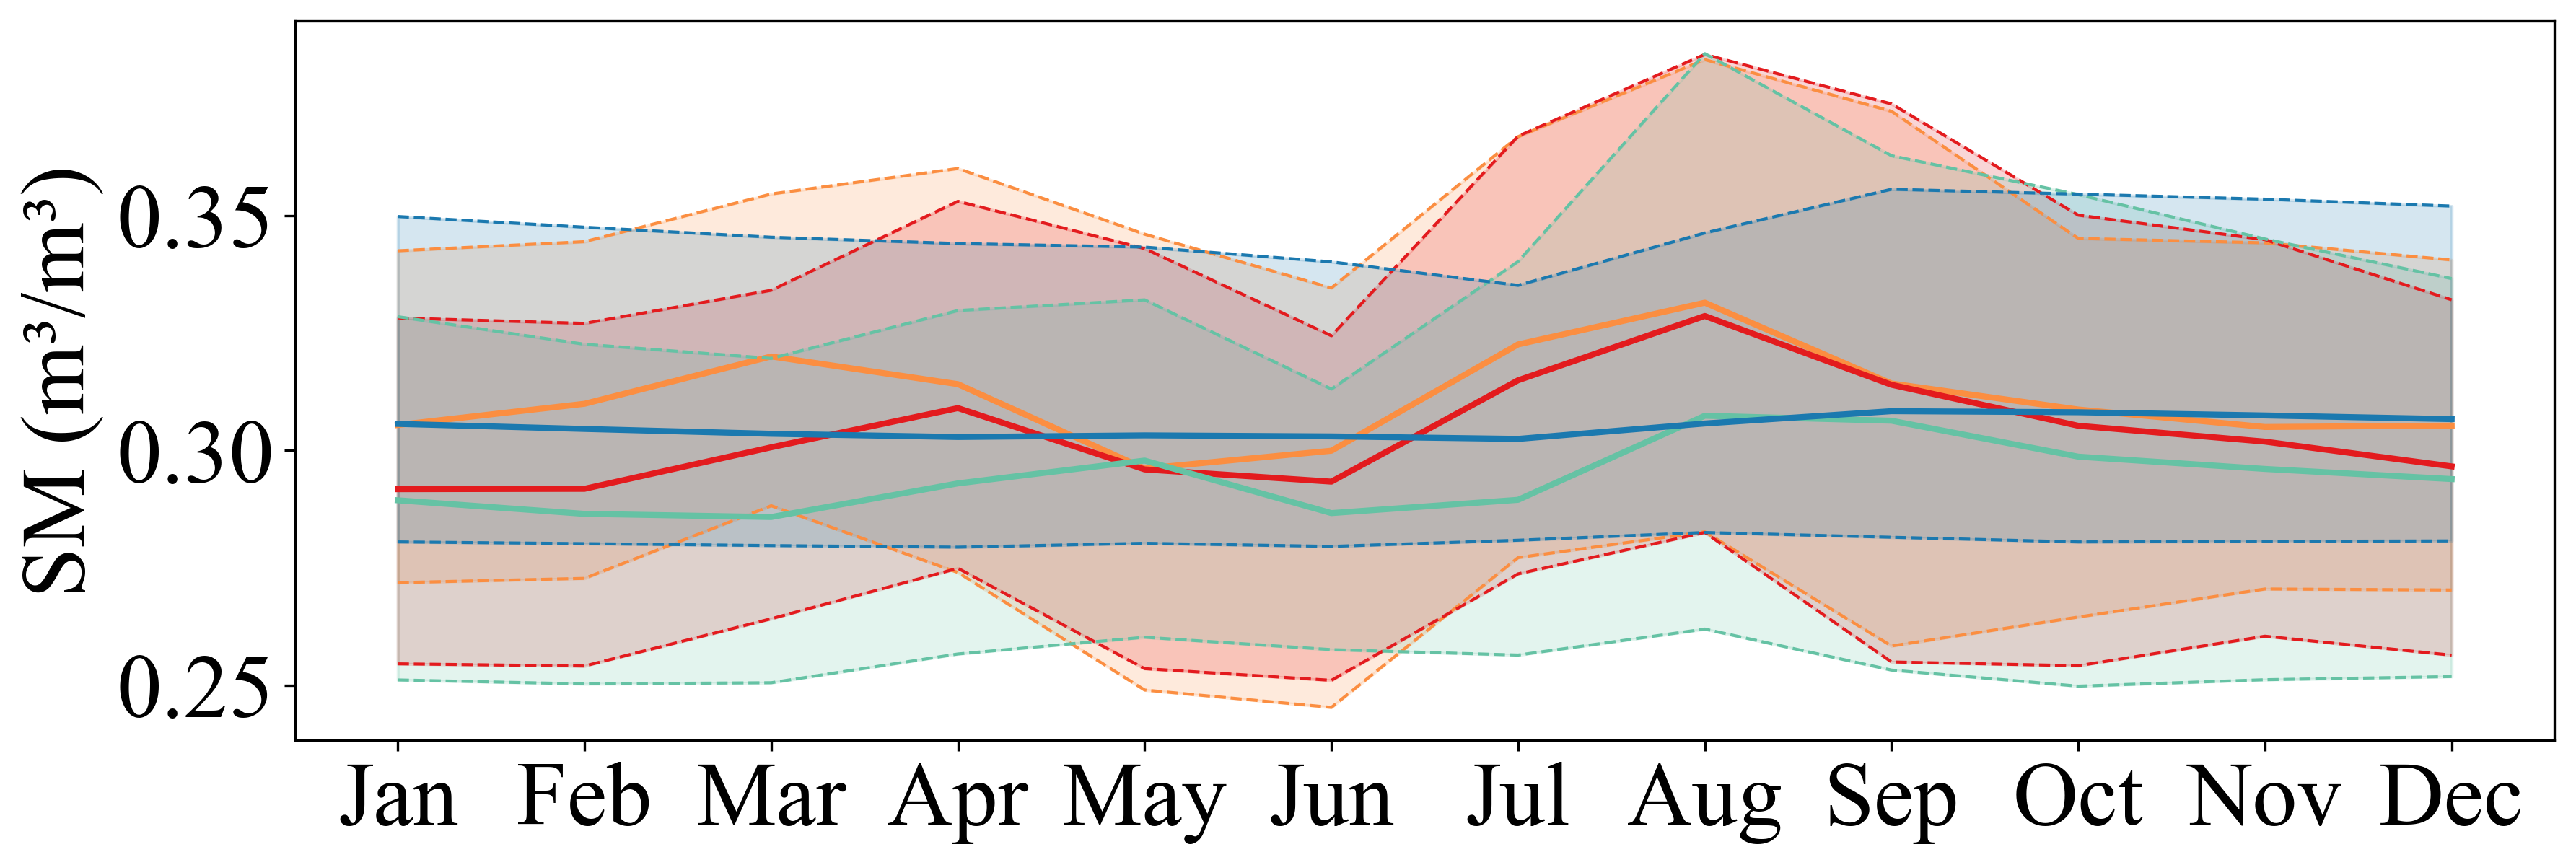

In [96]:
# 温度 25年上平均的12月趋势
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ========= 可修改区域 =========
excel_path = 'D:/Permafrost/EN_MASK/stmi/swvl/swvl.xlsx'  # << 替换为你的Excel路径
sheet_name = 'Sheet1'                             # 或者填写工作表名
layer_cols = ["swvl1", "swvl2", "swvl3", "swvl4"] # 如果列名不同，在这里改

# 如果只想用一个固定的25年窗口，打开下面两行：
# year_start, year_end = 1997, 2021           # << 示例：1997-2021 共25年（含端点）
year_start, year_end = None, None              # << 默认None表示用全时段
alpha_shade = 0.18                             # 阴影透明度
# ============================

# 读取
df = pd.read_excel(excel_path, sheet_name=sheet_name)
df.columns = [str(c).strip() for c in df.columns]

# 忽略 mean 列
df = df.drop(columns=[c for c in df.columns if c.lower() == "mean"], errors="ignore")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["year"]  = df["Date"].dt.year
df["month"] = df["Date"].dt.month

# 按需限制到 25 年窗口
if (year_start is not None) and (year_end is not None):
    df = df[(df["year"] >= year_start) & (df["year"] <= year_end)].copy()

# —— 计算统计量：每月多年均值、以及每月 across years 的最小/最大值 ——
# 多年均值（climatology）
mean_df = (df.groupby("month")[layer_cols].mean(numeric_only=True).reindex(range(1, 12 + 1)))

# 每月最小/最大（跨年份）
min_df = (
    df.groupby("month")[layer_cols]
      .min(numeric_only=True)
      .reindex(range(1, 12 + 1))
)
max_df = (
    df.groupby("month")[layer_cols]
      .max(numeric_only=True)
      .reindex(range(1, 12 + 1))
)

# —— 整理导出：tidy格式（month, layer, mean, min, max）——
records = []
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for layer in layer_cols:
    tmp = pd.DataFrame({
        "month": months,
        "layer": layer,
        "mean": mean_df[layer].values,
        "min":  min_df[layer].values,
        "max":  max_df[layer].values
    })
    records.append(tmp)
stats_tidy = pd.concat(records, ignore_index=True)

# —— 作图：同一张图里画四条均值曲线 + 对应的最小~最大阴影 ——
fig, ax = plt.subplots(figsize=(12, 4.1), dpi=300)
lab_ly = ["Layer1", "Layer2", "Layer3", "Layer4"]

# 为每层定义不同的阴影颜色
shade_colors = ['#fb8e41', '#e31b1e', '#65c2a4', '#1b79af']
y_offsets = [-5, -6, -7, -8]  # 可以根据实际温度范围调整这些值
# star_end_idx = [[4,9],[4,9],[5,10],[6,11]]
for ly,layer in enumerate(layer_cols):
    y_mean = mean_df[layer].values
    y_min  = min_df[layer].values
    y_max  = max_df[layer].values
        
    # 阴影：每层自己的 min~max（不在图例中显示，避免太拥挤）
    ax.fill_between(months, y_min, y_max, alpha=alpha_shade, color=shade_colors[ly], label="_nolegend_")
    ax.plot(months, y_min, color=shade_colors[ly], linewidth=1, linestyle='--')
    ax.plot(months, y_max, color=shade_colors[ly], linewidth=1, linestyle='--')
    # 多年均值曲线（在图例显示）
    ax.plot(months, y_mean, label=lab_ly[ly], color=shade_colors[ly], linewidth=2)
ax.set_xlim()
ax.set_xticks(list(months))
ax.tick_params(axis='both', labelsize=30)   # 调整x轴刻度字体大小
# ax.set_xlabel("Month", fontsize=30)
ax.set_ylabel("SM (m³/m³)", fontsize=30)   #Soil temperature (℃)  Soil water (m³/m³)
# ax.grid(True, which="both", linestyle="--", alpha=0.4)
# ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

In [ ]:
# import os   低效版趋势计算
# import numpy as np
# import rasterio
# from scipy.stats import norm
# from tqdm import tqdm
# from itertools import combinations
# # === 设置路径 ===
# data_dir = "D:/Permafrost/EN_MASK/stmi/stl/stl1_y.nc"
# output_path = "D:/Permafrost/EN_MASK/stmi/stl/result_1.nc"
# years = list(range(1997, 2022))  
# n_years = len(years)
# # === 读取第一个文件，获取元数据 ===
# ds = xr.open_dataset(data_dir)['stl1']
# # === 初始化输出数组 ===
# trend_result = np.full((173,225), np.nan)

# # === 定义Sen's slope函数 ===
# def sens_slope(x):    
#     slopes = [(x[j] - x[i]) / (j - i) for i, j in combinations(range(len(x)), 2)]   
#     return np.median(slopes)

# # === 开始逐像素分析 ===
# for lat in range(173):
#     for lon in range(225):
#         x = ds[:,lat,lon]    
#         # 判定有效像素（不能有全为0或NaN）    
#         if np.all(x <= 0) or np.any(np.isnan(x)):        
#             continue
#         # --- 计算Mann-Kendall S统计量 ---    
#         S = 0    
#         for j in range(1, n_years):        
#             for k in range(j):
#                 if x[j] > x[k]:
#                     S += 1
#                 elif x[j] < x[k]:
#                     S -= 1
#         # --- 计算Z值 ---    
#         VAR_S = n_years * (n_years - 1) * (2 * n_years + 5) / 18    
#         if S > 0:        
#             Z = (S - 1) / np.sqrt(VAR_S)    
#         elif S < 0:        
#             Z = (S + 1) / np.sqrt(VAR_S)    
#         else:        
#             Z = 0
#         # --- 计算Sen's slope ---    
#         sen = sens_slope(x)
#         # === 根据Z值与Sen值分类 ===    
#         absZ = abs(Z)
#         # === 根据以下规则分类趋势 ===    
#         if absZ >= 2.58 and sen > 0.0005:  # 极显著上升        
#             trend_result[lat][lon] = 3    
#         elif 1.96 <= absZ < 2.58 and sen > 0.0005:  # 显著上升        
#             trend_result[lat][lon] = 2    
#         elif 1.645 <= absZ < 1.96 and sen > 0.0005:  # 微显著上升        
#             trend_result[lat][lon] = 1    
#         elif absZ < 1.645 or abs(sen) < 0.0005:  # 不显著        
#             trend_result[lat][lon] = 0    
#         elif absZ >= 2.58 and sen < -0.0005:  # 极显著下降        
#             trend_result[lat][lon] = -3    
#         elif 1.96 <= absZ < 2.58 and sen < -0.0005:  # 显著下降        
#             trend_result[lat][lon] = -2    
#         elif 1.645 <= absZ < 1.96 and sen < -0.0005:  # 微显著下降        
#             trend_result[lat][lon] = -1
# trend_ds = xr.Dataset(
#     {'trend': (['lat', 'lon'], trend_result)},
#     coords={'lat': ds.coords['latitude'], 'lon': ds.coords['longitude']}
# )
# trend_ds.to_netcdf(output_path)